# Session 3 — Demo 3: Charts that don't lie

**What this demo covers.** Numbers we now summarize honestly; charts can still lie on our behalf. We commit the classic chart crimes on purpose, then fix them, polish one chart to report grade, and let an AI build an interactive version in one prompt.

Five rules:

1. **Bars start at zero.**
2. **Show spread, not just means; for two groups show the shapes.**
3. **The title says what is drawn; the conclusion goes underneath, in words.**
4. **Label the data: axes, units, and the numbers where they fit.**
5. **If you cut something out of a chart, say how much.**

**How we work.** Every crime is shown to you first as a chart with no warning. Decide what you conclude before you read on.

**Data.** Both warehouses — [data dictionary](../../data/README.md).

**How to run.** Locally: top to bottom. Colab: uncomment the lines in the setup cell. The AI-moment cell and the Extras cell need plotly (`%pip install plotly`).

## 0. Setup

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import AutoMinorLocator

# both warehouses live under data/
DATA = Path("../../data")

# --- Google Colab? Uncomment these two lines to fetch the course repo: ---
# !git clone https://github.com/seemsGoodNow/hse-data-science-course.git course
# DATA = Path("course/data")

# missing a library? uncomment:
# %pip install pandas pyarrow matplotlib seaborn plotly

In [2]:
# the helpers from Demo 1 again
def make_ax_better(ax, minor=""):
    """Tidy one chart: drop the top/right frame, add a light grid."""
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    if "x" in minor:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
    if "y" in minor:
        ax.yaxis.set_minor_locator(AutoMinorLocator())
    if minor:
        ax.tick_params(which="minor", length=2.5)
        ax.tick_params(which="major", length=5)
        ax.grid(which="minor", linewidth=0.15, color="tab:grey", alpha=0.25)
    ax.grid(linewidth=0.5, color="tab:grey", alpha=0.25)


ALPHA_COLOR, BRAVO_COLOR = "tab:blue", "tab:orange"

In [3]:
def compute_wrong_share(name):
    """Share of pick scans that grabbed the wrong item, for one site."""
    events = pd.read_parquet(DATA / name / "picking_events.parquet")
    n_correct = (events["event_type"] == "PickCorrectItem").sum()
    n_wrong = (events["event_type"] == "PickWrongItem").sum()
    return n_wrong / (n_correct + n_wrong)


alpha_error_share = compute_wrong_share("alpha")
bravo_error_share = compute_wrong_share("bravo")

print(
    f"wrong-scan share: ALPHA {alpha_error_share:.1%}, "
    f"BRAVO {bravo_error_share:.1%}"
)

wrong-scan share: ALPHA 18.6%, BRAVO 26.8%


## 1. ❓ "How bad is BRAVO, really?"

Look at the chart below. What do you conclude? Is anything wrong with it?

<details>
<summary>🔍 <b>What we'll do</b> — think first, then open</summary>

draw the two wrong-scan shares from the cell above, one bar per site.
</details>

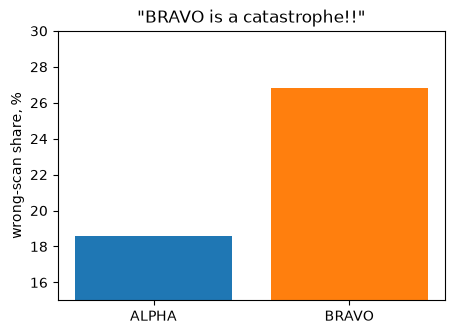

In [4]:
# plain matplotlib on purpose: this chart is the exhibit, not the example
fig, ax = plt.subplots(figsize=(5, 3.5))

ax.bar(
    ["ALPHA", "BRAVO"],
    [alpha_error_share * 100, bravo_error_share * 100],
    color=[ALPHA_COLOR, BRAVO_COLOR],
)
ax.set_ylim(15, 30)
ax.set_title('"BRAVO is a catastrophe!!"')
ax.set_ylabel("wrong-scan share, %")

plt.show()

### Crime #1 — the truncated axis

The y-axis starts at 15%, so BRAVO's visible bar is about three times ALPHA's; the numbers say 1.4 times.

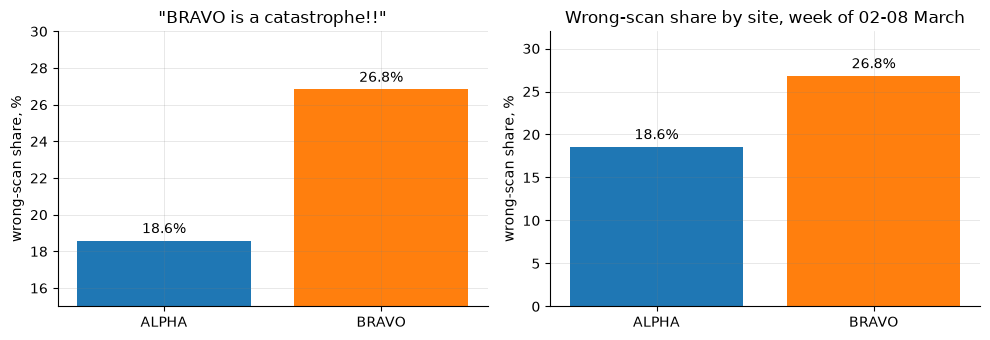

Conclusion: BRAVO's wrong-scan share is 1.4x ALPHA's (26.8% vs 18.6%).


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

for ax in axes:
    bars = ax.bar(
        ["ALPHA", "BRAVO"],
        [alpha_error_share * 100, bravo_error_share * 100],
        color=[ALPHA_COLOR, BRAVO_COLOR],
    )
    ax.bar_label(bars, fmt="%.1f%%", padding=3)
    ax.set_ylabel("wrong-scan share, %")
    make_ax_better(ax)

axes[0].set_ylim(15, 30)      # the crime: the bottom is cut off
axes[0].set_title('"BRAVO is a catastrophe!!"')
axes[1].set_ylim(0, 32)       # the fix: length starts at zero
axes[1].set_title("Wrong-scan share by site, week of 02-08 March")

plt.tight_layout()
plt.show()

# the conclusion lives here, in a sentence you can argue with
ratio = bravo_error_share / alpha_error_share
print(
    f"Conclusion: BRAVO's wrong-scan share is {ratio:.1f}x ALPHA's "
    f"({bravo_error_share:.1%} vs {alpha_error_share:.1%})."
)

✅ **What it means:** on the left, BRAVO's visible bar is about three times taller, so the eye reads *triple worse*. The data says 1.4 times. Nobody edited a number; **the axis did the lying.** Bars encode value by *length*, so length must start at zero. (Line charts may zoom; bars may not.)

⛔ **What it does NOT mean:** that everyone who does this is dishonest. Most truncated axes are the tool's default, or someone "making the difference visible". The result is the same whatever the intent, which is why the rule is mechanical, not a matter of taste.

### Crime #2 — the title that argues for you

Look at the exhibit once more. Its title was *"BRAVO is a catastrophe!!"*. Fixing the axis and writing *"BRAVO is 1.4x worse"* on top would still be a crime: both titles do the reader's thinking for them. The honest panel says only what is drawn, *wrong-scan share by site, week of 02-08 March*. The conclusion is the printed sentence underneath.

A conclusion in the title is not automatically false. It is simply not checkable. The reader sees the sentence before the shape, and from then on they are reading your opinion, not the data. And when the data updates, the title quietly becomes a lie.

**The rule: the title says what is drawn. The conclusion goes underneath, in words you can argue with.**

---

## 2. ❓ "Are the two sites really that different?"

Look at the chart below. What do you conclude? Is anything wrong with it?

<details>
<summary>🔍 <b>What we'll do</b> — think first, then open</summary>

the pace comparison from Demo 2: one number per site.
</details>

In [6]:
def build_task_table(name):
    """One row per finished task: successful picks and picks per hour, for one site."""
    events = pd.read_parquet(DATA / name / "picking_events.parquet")
    picks = events[events["event_type"] == "PickCorrectItem"]

    tasks = (
        events
        .groupby("task_id")
        .agg(
            start=("event_time", "min"),
            end=("event_time", "max"),
        )
    )
    tasks["picks"] = picks.groupby("task_id").size()

    finished_ids = set(events.loc[events["event_type"] == "FinishTask", "task_id"])
    tasks = tasks[tasks.index.isin(finished_ids) & (tasks["picks"] > 0)]

    hours = (tasks["end"] - tasks["start"]).dt.total_seconds() / 3600
    tasks["picks_per_hour"] = tasks["picks"] / hours
    return tasks


def build_pace_frame(name, label):
    """One long-form table: a picks_per_hour column plus the site it belongs to."""
    tasks = build_task_table(name)
    return pd.DataFrame({"picks_per_hour": tasks["picks_per_hour"], "site": label})


pace_by_site = pd.concat([
    build_pace_frame("alpha", "ALPHA"),
    build_pace_frame("bravo", "BRAVO"),
])
pace_by_site.head()

,picks_per_hour,site
task_id,,
800000001,64.469048,ALPHA
800000002,112.204149,ALPHA
800000003,92.536765,ALPHA
800000004,134.621377,ALPHA
800000005,67.975574,ALPHA


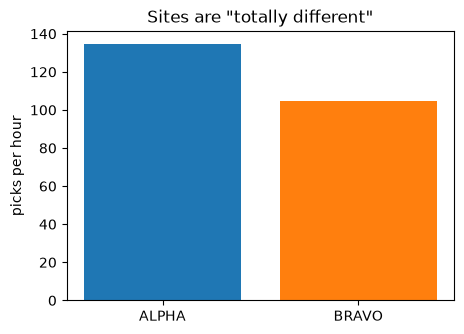

In [7]:
# plain matplotlib on purpose: this chart is the exhibit, not the example
site_means = pace_by_site.groupby("site")["picks_per_hour"].mean()

fig, ax = plt.subplots(figsize=(5, 3.5))

ax.bar(site_means.index, site_means, color=[ALPHA_COLOR, BRAVO_COLOR])
ax.set_title('Sites are "totally different"')
ax.set_ylabel("picks per hour")

plt.show()

### Crime #3 — means without spread

Each bar is one number, the mean of thousands of tasks; the chart hides how much those tasks overlap.

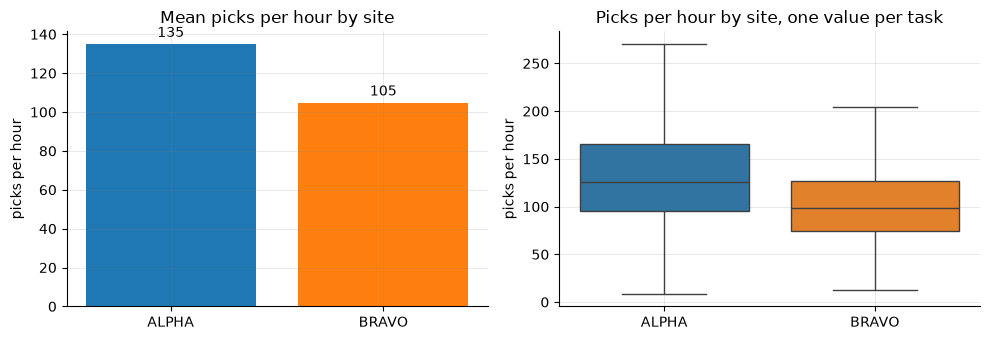

the boxes hide 165 tasks of 6,474 (2.5%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

bars = axes[0].bar(site_means.index, site_means, color=[ALPHA_COLOR, BRAVO_COLOR])
axes[0].bar_label(bars, fmt="%.0f", padding=3)
axes[0].set_title("Mean picks per hour by site")
axes[0].set_ylabel("picks per hour")

sns.boxplot(
    data=pace_by_site,
    x="site",
    y="picks_per_hour",
    hue="site",
    legend=False,
    showfliers=False,
    ax=axes[1],
)
axes[1].set_title("Picks per hour by site, one value per task")
axes[1].set_ylabel("picks per hour")
axes[1].set_xlabel("")

for ax in axes:
    make_ax_better(ax)

plt.tight_layout()
plt.show()

# rule 5: showfliers=False hid the outliers, so say how many
q1_by_site = pace_by_site.groupby("site")["picks_per_hour"].quantile(0.25)
q3_by_site = pace_by_site.groupby("site")["picks_per_hour"].quantile(0.75)
lower_fence = pace_by_site["site"].map(q1_by_site - 1.5 * (q3_by_site - q1_by_site))
upper_fence = pace_by_site["site"].map(q3_by_site + 1.5 * (q3_by_site - q1_by_site))
is_hidden = (
    (pace_by_site["picks_per_hour"] < lower_fence)
    | (pace_by_site["picks_per_hour"] > upper_fence)
)
print(
    f"the boxes hide {is_hidden.sum():,} tasks of {len(pace_by_site):,} "
    f"({is_hidden.mean():.1%})"
)

✅ **What it means:** the bars scream *different!*; the boxes admit that the two warehouses share most of their range. Both charts use true numbers; only one lets the reader judge. **Spread, or it didn't happen.**

⛔ **What it does NOT mean:** that the boxplot is automatically the honest choice. It hides its outliers by default, so it owes the debt every cut chart owes: the number printed under it (rule 5). And with only **two** groups the honest move is a pair of histograms (Demo 2): the boxes summarise, the histograms show the shape.

---

## 3. ❓ "Do bigger tasks go faster?"

A scatter plot, `ax.scatter(x, y)`, draws one dot per row: here one dot per task, x = picks in the task, y = picks per hour. `s=` is the dot size; `alpha=` is transparency (1 is solid, 0.1 is almost invisible).

Look at the chart below. Is there a relationship? What do you conclude?

<details>
<summary>🔍 <b>What we'll do</b> — think first, then open</summary>

take ALPHA's finished tasks from the table we already built and put every task on the plane.
</details>

In [9]:
alpha_tasks = build_task_table("alpha")
alpha_tasks.head()

,start,end,picks,picks_per_hour
task_id,,,,
800000001,2026-03-02 11:51:59.142,2026-03-02 12:03:09.231,12,64.469048
800000002,2026-03-02 12:05:24.017,2026-03-02 12:13:57.367,16,112.204149
800000003,2026-03-02 12:08:44.351,2026-03-02 12:38:33.910,46,92.536765
800000004,2026-03-02 12:13:59.691,2026-03-02 12:23:21.266,21,134.621377
800000005,2026-03-02 12:15:10.460,2026-03-02 12:19:35.261,5,67.975574


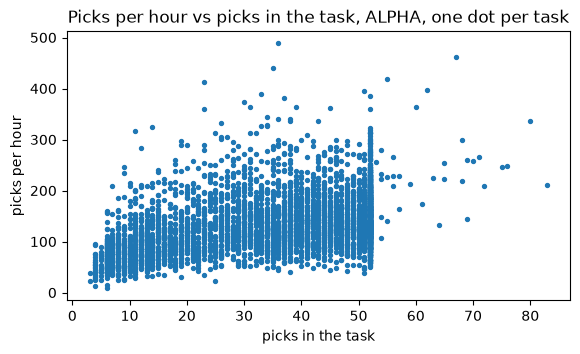

In [10]:
# plain matplotlib on purpose: this chart is the exhibit, not the example
fig, ax = plt.subplots(figsize=(6.5, 3.5))

ax.scatter(alpha_tasks["picks"], alpha_tasks["picks_per_hour"], s=8)
ax.set_title("Picks per hour vs picks in the task, ALPHA, one dot per task")
ax.set_xlabel("picks in the task")
ax.set_ylabel("picks per hour")

plt.show()

### Crime #4 — a scatter with too many dots

4,077 dots on one small panel become a blob; the eye cannot tell a trend from noise, so any answer you gave was a guess.

The fix is not a prettier scatter. It is to **aggregate**: put tasks into size buckets, take a median per bucket, and show how many tasks each bucket holds.

**Step 1: `pd.cut`.** It turns a number into a bucket label, using a list of edges: `bins=[0, 10, 20]` gives the buckets `(0, 10]` and `(10, 20]`. The round bracket means the left edge is excluded, the square bracket means the right edge is included. Not sure how it works? Five numbers where you know the answer:

In [11]:
toy_sizes = pd.Series([3, 12, 18, 27, 45])
pd.cut(toy_sizes, bins=[0, 10, 20, 30, 50])

0     (0, 10]
1    (10, 20]
2    (10, 20]
3    (20, 30]
4    (30, 50]
dtype: category
Categories (4, interval[int64, right]): [(0, 10] < (10, 20] < (20, 30] < (30, 50]]

3 lands in `(0, 10]`, 12 and 18 in `(10, 20]`, 27 in `(20, 30]`, 45 in `(30, 50]`. Now the real column. The biggest ALPHA task must fit under the last edge, and a value outside the edges becomes an empty label, so we count those too.

In [12]:
alpha_tasks["size_bucket"] = pd.cut(
    alpha_tasks["picks"],
    bins=[0, 10, 20, 30, 40, 50, 60, 80, 90],
)

print(
    f"biggest task: {alpha_tasks['picks'].max()} picks; "
    f"tasks outside the bins: {alpha_tasks['size_bucket'].isna().sum()}"
)
alpha_tasks.head()

biggest task: 83 picks; tasks outside the bins: 0


,start,end,picks,picks_per_hour,size_bucket
task_id,,,,,
800000001,2026-03-02 11:51:59.142,2026-03-02 12:03:09.231,12,64.469048,"(10, 20]"
800000002,2026-03-02 12:05:24.017,2026-03-02 12:13:57.367,16,112.204149,"(10, 20]"
800000003,2026-03-02 12:08:44.351,2026-03-02 12:38:33.910,46,92.536765,"(40, 50]"
800000004,2026-03-02 12:13:59.691,2026-03-02 12:23:21.266,21,134.621377,"(20, 30]"
800000005,2026-03-02 12:15:10.460,2026-03-02 12:19:35.261,5,67.975574,"(0, 10]"


**Step 2: one row per bucket.** `groupby("size_bucket")` as in session 2; `observed=True` keeps only buckets that hold at least one task.

In [13]:
pace_by_size = (
    alpha_tasks
    .groupby("size_bucket", observed=True)
    .agg(
        tasks_in_bucket=("picks_per_hour", "size"),
        median_pace=("picks_per_hour", "median"),
    )
)
pace_by_size

,tasks_in_bucket,median_pace
size_bucket,,
"(0, 10]",364,73.190981
"(10, 20]",600,100.973790
"(20, 30]",519,127.084137
"(30, 40]",742,128.630042
"(40, 50]",807,138.625896
"(50, 60]",1027,142.466079
"(60, 80]",17,248.377738
"(80, 90]",1,211.243708


**Step 3: draw the buckets, and put one number next to the picture.** `.corr(method="spearman")` is the rank correlation between two columns: +1 means bigger is always faster, 0 means no relation, -1 means bigger is always slower.

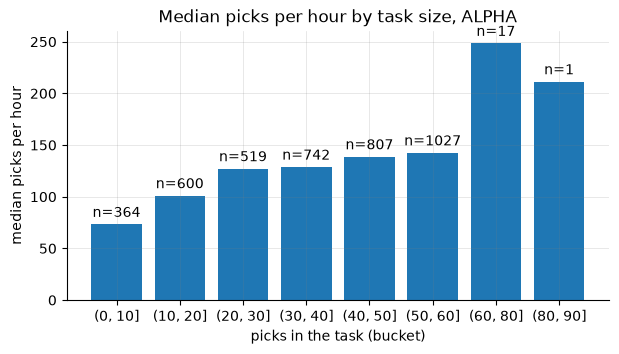

Rank correlation between task size and pace: 0.41 (+1 = bigger is always faster, 0 = no relation).
Only 18 tasks have more than 60 picks: 17 in the (60, 80] bucket and 1 in (80, 90].


In [14]:
fig, ax = plt.subplots(figsize=(7, 3.5))

bucket_labels = pace_by_size.index.astype(str)
bars = ax.bar(bucket_labels, pace_by_size["median_pace"], color=ALPHA_COLOR)
ax.bar_label(
    bars,
    labels="n=" + pace_by_size["tasks_in_bucket"].astype(str),
    padding=3,
)
ax.set_title("Median picks per hour by task size, ALPHA")
ax.set_xlabel("picks in the task (bucket)")
ax.set_ylabel("median picks per hour")
make_ax_better(ax)

plt.show()

rank_corr = alpha_tasks["picks"].corr(alpha_tasks["picks_per_hour"], method="spearman")
tasks_over_60 = (alpha_tasks["picks"] > 60).sum()
tasks_over_80 = (alpha_tasks["picks"] > 80).sum()
print(
    f"Rank correlation between task size and pace: {rank_corr:.2f} "
    f"(+1 = bigger is always faster, 0 = no relation)."
)
print(
    f"Only {tasks_over_60} tasks have more than 60 picks: "
    f"{tasks_over_60 - tasks_over_80} in the (60, 80] bucket "
    f"and {tasks_over_80} in (80, 90]."
)

✅ **What it means:** the trend is real and modest. Medians climb from about 73 picks per hour in the smallest tasks to about 143 in the 50–60 bucket, and the rank correlation is 0.41. The blob hid a relationship that seven bars and one number show.

⛔ **What it does NOT mean:** that the last two bars mean anything: 17 tasks and 1 task prove nothing (rule 5 again: nothing was cut, but two buckets are nearly empty, and the labels say so). Nor that "bigger tasks are faster per item" turns into "give everyone big tasks". And this is the **shape** of HW1 hypothesis 1; the number on your own site is yours to find.

---

## 4. From default to report-grade

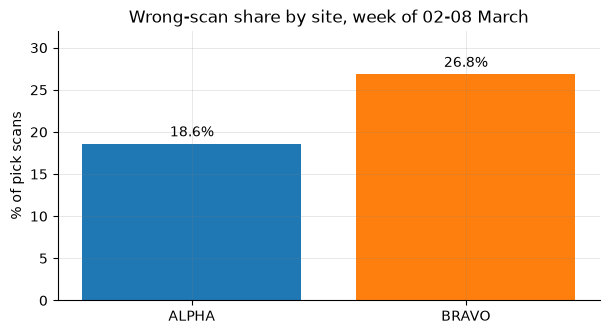

Conclusion: BRAVO's wrong-scan share is 1.4x ALPHA's (26.8% vs 18.6%).


In [15]:
fig, ax = plt.subplots(figsize=(7, 3.5))

bars = ax.bar(
    ["ALPHA", "BRAVO"],
    [alpha_error_share * 100, bravo_error_share * 100],
    color=[ALPHA_COLOR, BRAVO_COLOR],
)
ax.bar_label(bars, fmt="%.1f%%", padding=3)      # (4) label the data itself
ax.set_title("Wrong-scan share by site, week of 02-08 March")   # (3) what is drawn
ax.set_ylabel("% of pick scans")                 # (4) units on the axis
ax.set_ylim(0, 32)                               # (1) bars from zero
make_ax_better(ax)

plt.show()

# (3) the conclusion lives here, in a sentence you can argue with
ratio = bravo_error_share / alpha_error_share
print(
    f"Conclusion: BRAVO's wrong-scan share is {ratio:.1f}x ALPHA's "
    f"({bravo_error_share:.1%} vs {alpha_error_share:.1%})."
)

A manager reads this in three seconds and takes away exactly one sentence: the sentence underneath. That's the job.

## 5. The AI moment — interactive in one prompt

The prompt (role, data description, what I want, constraints):

> You are a Python data analyst. I have two numbers: wrong-scan share ALPHA=0.186, BRAVO=0.268. Using plotly, build a bar chart with hover showing exact percentages, title "Wrong-scan share by site, week of 02-08 March", bars from zero, and save it as a self-contained HTML file `two-warehouses.html`. Return only the code.

Below is the returned code. In plotly, `go.Figure` holds the chart, `go.Bar` is one set of bars, `update_layout` sets the title and the axes, and `write_html` saves the file. Read it, run it, **verify the numbers against the matplotlib version**, then open the file in a browser:

In [16]:
# - code returned by the assistant; read every line, then run -
# %pip install plotly
import plotly.graph_objects as go

fig = go.Figure(go.Bar(
    x=["ALPHA", "BRAVO"],
    y=[alpha_error_share * 100, bravo_error_share * 100],
    # hover text; <extra></extra> hides plotly's extra box with the trace name
    hovertemplate="%{x}: %{y:.1f}%<extra></extra>",
))
fig.update_layout(
    title="Wrong-scan share by site, week of 02-08 March",
    yaxis=dict(title="wrong-scan share, %", range=[0, 32]),
)
fig.write_html("two-warehouses.html", include_plotlyjs=True)

size_mb = Path("two-warehouses.html").stat().st_size / 1e6
print(f"two-warehouses.html: {size_mb:.1f} MB - open it in a browser")

two-warehouses.html: 4.9 MB - open it in a browser


One prompt → a file you can send to anyone; it opens in a browser with working hover and no Python required. This exact move is the **HW1 bonus one-pager**, and the session-7 finale in miniature. As always: the assistant wrote it, *you* verified the numbers.

## Before you show a chart — the checklist

1. Bars start at zero?
2. Spread shown, not just means? For two groups, the shapes?
3. Does the title say **what is drawn**, with the conclusion underneath, in words?
4. Data labeled: axes, units, and the numbers where they fit?
5. Cut something out (outliers, a range, small buckets)? Did you say how much?

## Try it yourself

1. Make the honest, polished version of **picks per worker** for the two warehouses (numbers are in Demo 2's scoreboard).
2. Find a chart crime in the wild (news, corporate deck) and name the rule it breaks.
3. Stretch: one prompt → an interactive version of *your* chart from task 1.

In [17]:
# your turn

## ⚡ Extras — power tools, not required

Plotly express, `px.histogram`, draws the Demo 2 histogram pair with hover: point at a bar and read the exact share. Not required for anything in this course.

In [18]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "notebook_connected"  # small notebook file; needs internet once
fig = px.histogram(
    pace_by_site,
    x="picks_per_hour",
    color="site",
    barmode="overlay",
    histnorm="percent",
    marginal="box",
    nbins=60,
    title="Picks per hour by site, hover for exact values",
)
fig.show()

## Recap

- Truncated bar axes turn 1.4x into 3x. Bars start at zero, always.
- Means without spread overstate differences. Boxes or quantiles, and for two groups, histograms.
- **The title says what is drawn; the conclusion goes underneath in words.** A title that argues is not checkable, and it rots when the data updates.
- Too many dots hide the trend. Aggregate into buckets, show the median per bucket and how many rows each bucket holds.
- Label the data itself; delete lines and labels that carry no information.
- Cut something out? Say how much: hidden outliers, a zoomed range, a nearly empty bucket.
- AI builds interactive HTML in one prompt; you verify the numbers before shipping.

*HW1 is out tonight — the researcher's story on your personal slice. Next week: how to tell a real difference from luck (p-values, with pictures).*